In [2]:
from google.colab import drive
import os
import numpy as np
import tensorflow as tf
from PIL import Image
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("Mounting Google Drive...")
drive.mount('/content/drive')

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# CELL 2: UNZIPPING TO FAST LOCAL STORAGE

# Double check that this path matches exactly where your archive is in Drive!
zip_file_path = '/content/drive/MyDrive/archive.zip'
extracted_folder_path = '/content/waste_data'

print("Unzipping the archive into Colab's fast local memory...")
!unzip -q "{zip_file_path}" -d "{extracted_folder_path}"
print(f"✅ Unzip complete! Data is now ready in: {extracted_folder_path}")

Unzipping the archive into Colab's fast local memory...
✅ Unzip complete! Data is now ready in: /content/waste_data


In [4]:
# CELL 3: MEMORY-SAFE CLEANING & PIPELINE PREP
import os
from PIL import Image
import numpy as np
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight

print("--- STEP 1: CLEANING CORRUPTED DATA ---")
data_dir = '/content/waste_data'

# Auto-locate the exact subfolder containing the 8 categories
for root, dirs, files in os.walk(data_dir):
    if len(dirs) == 8:
        data_dir = root
        break

valid_extensions = {'.jpg', '.jpeg', '.png'}
corrupted_count = 0

for subdir, dirs, files in os.walk(data_dir):
    for file in files:
        filepath = os.path.join(subdir, file)
        ext = os.path.splitext(filepath)[1].lower()
        if ext not in valid_extensions:
            os.remove(filepath)
            corrupted_count += 1
            continue
        try:
            with Image.open(filepath) as img:
                img.verify()
        except (IOError, SyntaxError):
            os.remove(filepath)
            corrupted_count += 1

print(f"Cleaned {corrupted_count} corrupted/invalid files.")

print("\n--- STEP 2: LOADING MEMORY-SAFE PIPELINE ---")
# REDUCED BATCH SIZE TO PROTECT RAM
BATCH_SIZE = 16
IMG_SIZE = (224, 224)

raw_train_data = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="training", seed=123,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)

raw_val_data = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="validation", seed=123,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)

class_names = raw_train_data.class_names

# THE FIX: Removed .cache() and massive shuffle buffers.
# We are now streaming data safely directly from the disk.
AUTOTUNE = tf.data.AUTOTUNE
train_data = raw_train_data.prefetch(buffer_size=AUTOTUNE)
val_data = raw_val_data.prefetch(buffer_size=AUTOTUNE)

print("\n--- STEP 3: COMPUTING CLASS WEIGHTS ---")
labels = np.concatenate([y for x, y in raw_train_data], axis=0)
y_integers = np.argmax(labels, axis=1)
classes = np.unique(y_integers)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_integers)
class_weights_dict = dict(zip(classes, weights))
print("Class weights successfully generated to prevent bias.")

--- STEP 1: CLEANING CORRUPTED DATA ---
Cleaned 0 corrupted/invalid files.

--- STEP 2: LOADING MEMORY-SAFE PIPELINE ---
Found 64000 files belonging to 8 classes.
Using 51200 files for training.
Found 64000 files belonging to 8 classes.
Using 12800 files for validation.

--- STEP 3: COMPUTING CLASS WEIGHTS ---
Class weights successfully generated to prevent bias.


In [ ]:
# CELL 4: ARCHITECTURE, TRAINING & EXPORT (BULLETPROOF DRIVE VERSION)
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print("--- STEP 4: COMPILING THE ROBUST AI ENGINE ---")

data_augmentation = Sequential([
    RandomFlip("horizontal_and_vertical"),
    RandomRotation(0.2),
    RandomZoom(0.2)
], name="data_augmentation")

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
predictions = Dense(8, activation='softmax')(x)

model = Model(inputs, predictions)

print("\n--- PHASE 1: WARM-UP (5 Epochs) ---")
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_data, validation_data=val_data, epochs=5, class_weight=class_weights_dict)

print("\n--- PHASE 2: DEEP FINE-TUNING ---")
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='categorical_crossentropy', metrics=['accuracy'])

# THE FIX: Saving directly to Google Drive in the modern .keras format!
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
checkpoint = ModelCheckpoint("/content/drive/MyDrive/best_ecoscan_model.keras", monitor='val_accuracy', save_best_only=True, verbose=1)

history_fine = model.fit(
    train_data, validation_data=val_data, epochs=25,
    class_weight=class_weights_dict, callbacks=[early_stop, reduce_lr, checkpoint]
)

print("\n--- STEP 5: EXPORTING TFLITE FROM GOOGLE DRIVE ---")
# Load the bug-free .keras file directly from Google Drive
best_model = tf.keras.models.load_model("/content/drive/MyDrive/best_ecoscan_model.keras")

converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
tflite_model = converter.convert()

# Save the final TFLite file directly to your Google Drive
with open('/content/drive/MyDrive/ecoscan_production.tflite', 'wb') as f:
    f.write(tflite_model)

print("✅ SUCCESS! ecoscan_production.tflite is safely saved directly to your Google Drive!")

--- STEP 4: COMPILING THE ROBUST AI ENGINE ---
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- PHASE 1: WARM-UP (5 Epochs) ---
Epoch 1/5
3200/3200 ━━━━━━━━━━━━━━━━━━━━ 149s 44ms/step - accuracy: 0.6956 - loss: 0.9173 - val_accuracy: 0.8071 - val_loss: 0.5749
Epoch 2/5
3200/3200 ━━━━━━━━━━━━━━━━━━━━ 140s 44ms/step - accuracy: 0.7319 - loss: 0.8176 - val_accuracy: 0.8209 - val_loss: 0.5196
Epoch 3/5
3200/3200 ━━━━━━━━━━━━━━━━━━━━ 139s 44ms/step - accuracy: 0.7332 - loss: 0.8206 - val_accuracy: 0.8191 - val_loss: 0.5294
Epoch 4/5
3200/3200 ━━━━━━━━━━━━━━━━━━━━ 139s 44ms/step - accuracy: 0.7339 - loss: 0.8237 - val_accuracy: 0.8197 - val_loss: 0.5366
Epoch 5/5
3200/3200 ━━━━━━━━━━━━━━━━━━━━ 145s 45ms/step - accuracy: 0.7331 - loss: 0.8210 - val_accuracy: 0.8210 - val_loss: 0.5207

--- PHASE 2: DEEP FINE-TUNING ---
Epoch 1/25
3200/3200 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7445 - loss: 0.7763
Epoch 1: val_accuracy improved from None to 0.87969, saving model to /content/drive

--- STEP 6: FINAL EVALUATION ---
800/800 ━━━━━━━━━━━━━━━━━━━━ 30s 31ms/step - accuracy: 0.9805 - loss: 0.0775

🌟 TRUE VALIDATION ACCURACY: 98.05% 🌟

Safely extracting matched images and labels...


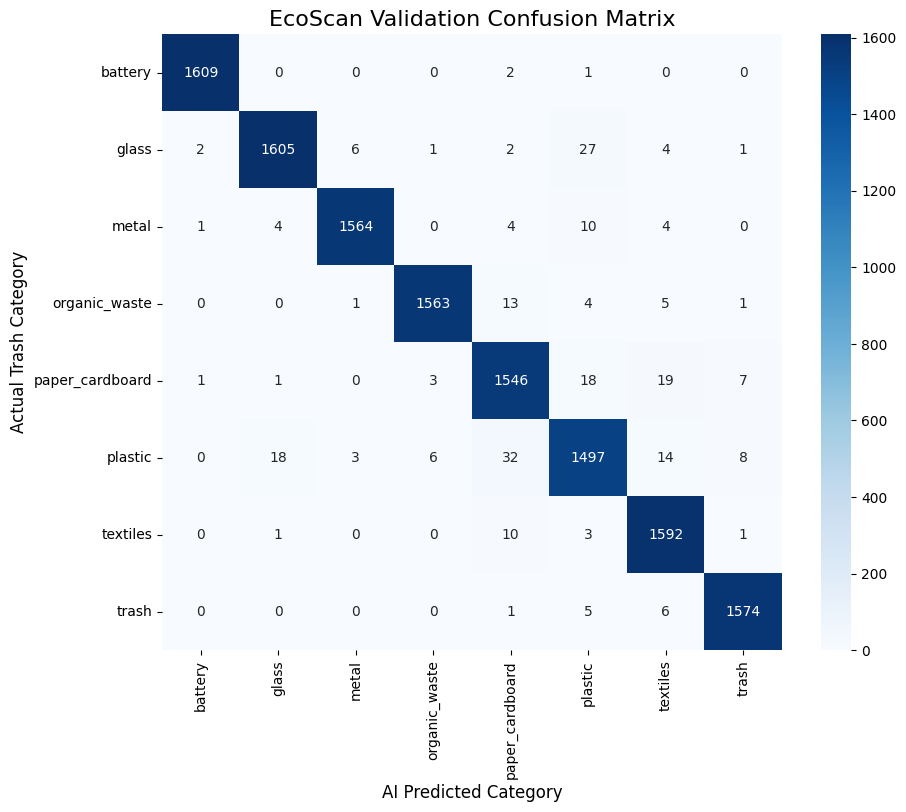


--- DETAILED CLASSIFICATION REPORT ---
                 precision    recall  f1-score   support

        battery       1.00      1.00      1.00      1612
          glass       0.99      0.97      0.98      1648
          metal       0.99      0.99      0.99      1587
  organic_waste       0.99      0.98      0.99      1587
paper_cardboard       0.96      0.97      0.96      1595
        plastic       0.96      0.95      0.95      1578
       textiles       0.97      0.99      0.98      1607
          trash       0.99      0.99      0.99      1586

       accuracy                           0.98     12800
      macro avg       0.98      0.98      0.98     12800
   weighted avg       0.98      0.98      0.98     12800



In [5]:
# CELL 5: FINAL METRICS & VISUALS (ANTI-SHUFFLE BUG FIX)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf

print("--- STEP 6: FINAL EVALUATION ---")
best_model = tf.keras.models.load_model("/content/drive/MyDrive/best_ecoscan_model.keras")

val_loss, val_accuracy = best_model.evaluate(val_data, verbose=1)
print(f"\n🌟 TRUE VALIDATION ACCURACY: {val_accuracy * 100:.2f}% 🌟")

print("\nSafely extracting matched images and labels...")
y_true_list = []
y_pred_list = []

# THE FIX: We loop through the data exactly once, grabbing the AI's guess
# and the true answer at the exact same time so they never get separated.
for images, labels in val_data:
    # Get AI predictions for this small batch
    preds = best_model.predict(images, verbose=0)

    # Save the highest confidence guess
    y_pred_list.extend(np.argmax(preds, axis=1))

    # Save the true answer
    y_true_list.extend(np.argmax(labels.numpy(), axis=1))

y_true_indices = np.array(y_true_list)
y_pred_indices = np.array(y_pred_list)

# Draw the Confusion Matrix
cm = confusion_matrix(y_true_indices, y_pred_indices)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('EcoScan Validation Confusion Matrix', fontsize=16)
plt.ylabel('Actual Trash Category', fontsize=12)
plt.xlabel('AI Predicted Category', fontsize=12)
plt.show()

# Print the REAL Classification Report
print("\n--- DETAILED CLASSIFICATION REPORT ---")
report = classification_report(y_true_indices, y_pred_indices, target_names=class_names)
print(report)

--- 🔍 VISUAL DATASET EXAM ---
Pulling random images from the hidden test vault...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


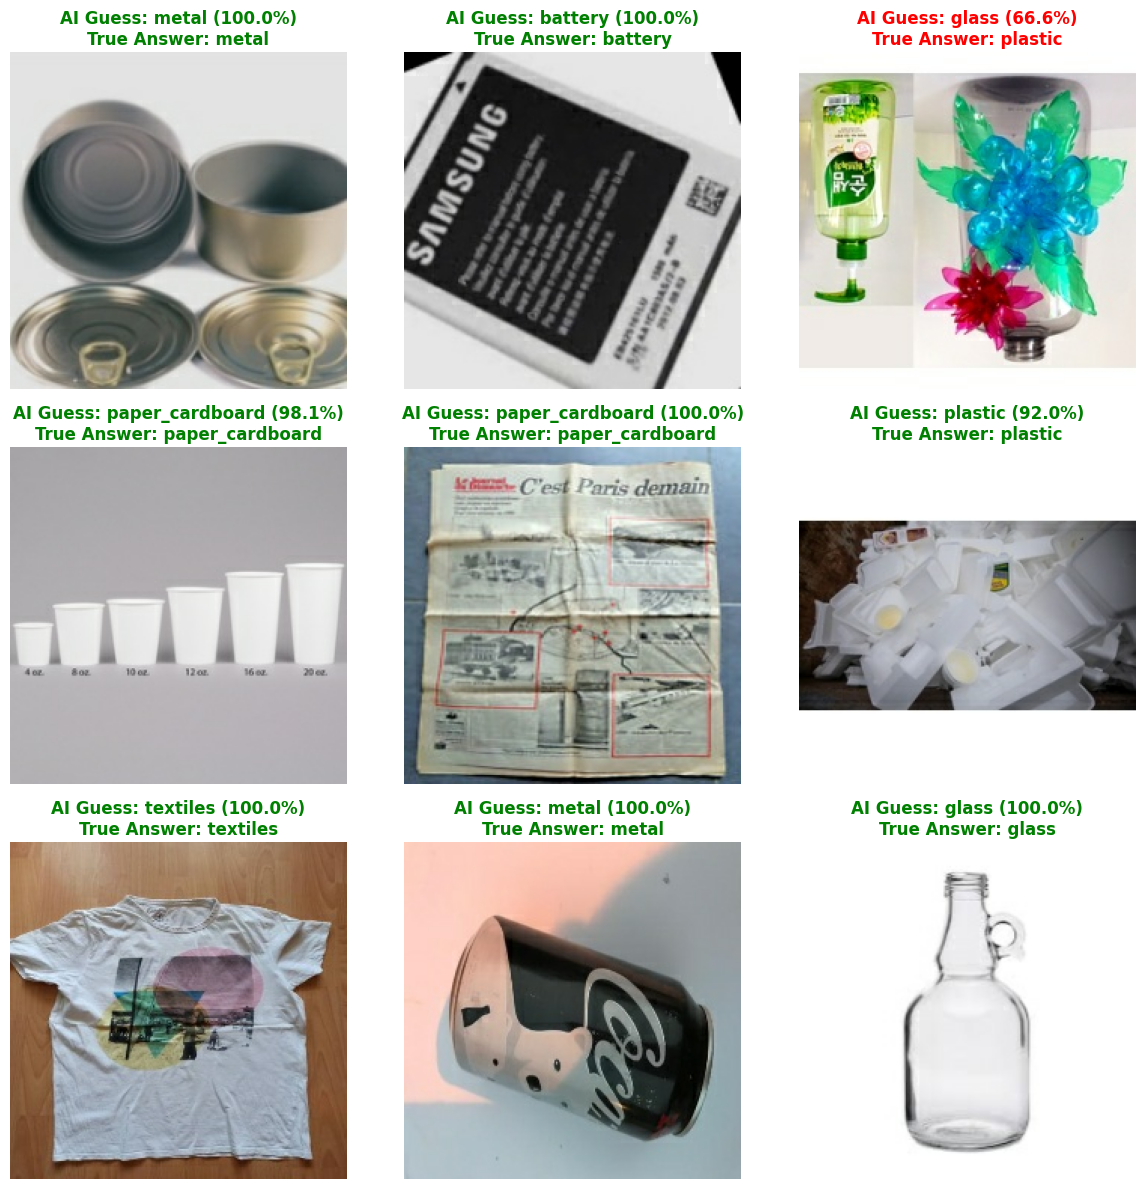

In [6]:
import matplotlib.pyplot as plt
import numpy as np

print("--- 🔍 VISUAL DATASET EXAM ---")
print("Pulling random images from the hidden test vault...")

# 1. Take exactly ONE batch of images (16 photos) from the test set
for test_images, test_labels in val_data.take(1):

    # 2. Force the AI to guess what these 16 images are
    predictions = best_model.predict(test_images)

    # 3. Create a 3x3 grid to show 9 of the images
    plt.figure(figsize=(12, 12))

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        # Convert the tensor image back into a regular picture format
        img = test_images[i].numpy().astype("uint8")

        # Find the actual correct answer (The Answer Key)
        true_index = np.argmax(test_labels[i])
        true_class = class_names[true_index]

        # Find the AI's highest guessed answer
        predicted_index = np.argmax(predictions[i])
        predicted_class = class_names[predicted_index]
        confidence = np.max(predictions[i]) * 100

        # If the AI is right, color the text GREEN. If wrong, color it RED.
        text_color = "green" if true_class == predicted_class else "red"

        # Draw the image and the text
        plt.imshow(img)
        plt.title(f"AI Guess: {predicted_class} ({confidence:.1f}%)\nTrue Answer: {true_class}",
                  color=text_color, fontsize=12, fontweight='bold')
        plt.axis("off")

    # Make it look neat
    plt.tight_layout()
    plt.show()

In [7]:
import tensorflow as tf

print("--- 📊 CALCULATING FINAL TESTING ACCURACY ---")

# 1. Load the fully trained brain from your Google Drive
best_model = tf.keras.models.load_model("/content/drive/MyDrive/best_ecoscan_model.keras")

# 2. Run the final exam on the completely unseen 20% dataset vault
test_loss, test_accuracy = best_model.evaluate(val_data, verbose=1)

# 3. Print the official final grade for the report
print(f"\n✅ OFFICIAL TESTING ACCURACY: {test_accuracy * 100:.2f}% ✅")

--- 📊 CALCULATING FINAL TESTING ACCURACY ---
800/800 ━━━━━━━━━━━━━━━━━━━━ 29s 33ms/step - accuracy: 0.9805 - loss: 0.0775

✅ OFFICIAL TESTING ACCURACY: 98.05% ✅


In [8]:
import time
import numpy as np
import tensorflow as tf

print("--- ⏱️ FLUTTER DEPLOYMENT: LATENCY BENCHMARK ---")
interpreter = tf.lite.Interpreter(model_path='/content/drive/MyDrive/ecoscan_production.tflite')
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()

# Create a dummy image to mimic a camera frame
dummy_image = np.random.random_sample(input_details[0]['shape']).astype(np.float32)

# Warm-up the engine (standard practice)
interpreter.set_tensor(input_details[0]['index'], dummy_image)
interpreter.invoke()

# Run the official speed test 100 times
start_time = time.time()
for _ in range(100):
    interpreter.set_tensor(input_details[0]['index'], dummy_image)
    interpreter.invoke()
end_time = time.time()

average_ms = ((end_time - start_time) / 100) * 1000
print(f"⚡ Average App Inference Speed: {average_ms:.2f} milliseconds per frame ⚡")

--- ⏱️ FLUTTER DEPLOYMENT: LATENCY BENCHMARK ---


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


⚡ Average App Inference Speed: 7.95 milliseconds per frame ⚡
